In [3]:
import pandas as pd
import csv
import re
import pandas as pd
import numpy as np
from datasets import load_dataset

# Dictionary creation
### Made a collection of data from different sets here. Saved as a .csv file so the dictionary did not have to e created with each kernel reset. Changed code to markdown to avoid running

afinn_wl_url = ('https://raw.githubusercontent.com'
                '/fnielsen/afinn/master/afinn/data/AFINN-en-165.txt')
                
url_emoji = ('https://raw.githubusercontent.com'
                '/fnielsen/afinn/master/afinn/data/AFINN-emoticon-8.txt')
                
words = pd.read_csv(afinn_wl_url,
                          header=None, # no column names
                          sep='\t',  # tab sepeated
                          names=['term', 'value']) #new column names
                          
emoji = pd.read_csv(url_emoji,
                          header=None, # no column names
                          sep='\t',  # tab sepeated
                          names=['term', 'value']) #new column names

seed = 808 # seed for sample so results are stable

lexi = pd.concat([words,emoji], ignore_index=True)
"""gathering words with strong sentiment"""

print(f"Loaded {len(lexi)} sentiment words + emoticons")

file = "/kaggle/input/english-word-frequency/unigram_freq.csv"

dicti = pd.read_csv(file)

dictionary = dicti['word'].to_numpy()
terms = lexi["term"].str.lower().to_numpy()

to_add = [[w, 0] for w in dictionary if w not in terms]

print(len(to_add))

col_names = ['term','value']

neutral = pd.DataFrame(to_add, columns=col_names)

lex = pd.concat([lexi,neutral], ignore_index=True)
print(lex)

"""add more generic/neutral words and label 0"""

"""print("add more sensitive words/ words already flagged typically by social media platforms and flag")


dataset = load_dataset("mmathys/profanity")

df = dataset["train"].to_pandas()

new = df[["text","severity_rating"]].copy()

new["severity_rating"] = new["severity_rating"].round().astype(int)

new["severity_rating"] = new["severity_rating"] * -2

new["text"] = new["text"].str.replace(" ", "-", regex=False)

new = new.rename(columns={"text": "term", "severity_rating": "value"})

missing = lex[~lex["term"].isin(new["term"])]

lex = pd.concat([new, missing], ignore_index=True)"""

In [ ]:
"""Save dictionary as a .csv file to avoid re-creating everytime kernel is restarted"""
"""
lex = lex.sample(frac=1).reset_index(drop=True)

print(lex)

dictionary = dict(zip(lex['term'], lex['value']))"""

In [ ]:
"""for k, v in list(dictionary.items())[:10]:
    print(k, v)"""

In [10]:
df = pd.read_csv("/kaggle/input/dictionary-words/dictionary_saved (1).csv")
df = df.sample(frac=1).reset_index(drop=True)
dictionary = df.set_index(df.columns[0])[df.columns[1]].to_dict()

In [11]:
emoticon_pattern = r'(:-?\)|:-?\(|;-\)?|:-?D|:-?P|:-?O|:-?S)'
import string

# punctuation we want to remove
punct = string.punctuation.replace(":", "").replace(";", "").replace("-","")

# remove punctuation unless it's part of an emoticon
def clean_text(text):
    text = text.lower()

    # temporarily mask emoticons
    emoticons = re.findall(emoticon_pattern, text)
    for i, emo in enumerate(emoticons):
        text = text.replace(emo, f"__EMO_{i}__")

    # remove punctuation normally
    text = text.translate(str.maketrans("", "", punct))

    # restore emoticons
    for i, emo in enumerate(emoticons):
        text = text.replace(f"__EMO_{i}__", emo)

    # collapse spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text



In [12]:
dataset = '/kaggle/input/hate-speech-and-offensive-language-dataset/labeled_data.csv'
df = pd.read_csv(dataset)
df = df.sample(frac=1).reset_index(drop=True)
raw = df['tweet']
dictionary ; 
terms = list(dictionary.keys())

divided_words = []

for i in range(2000):
    cleaned = clean_text(raw[i])
    divided_words.append(cleaned.split(" "))
print("done with that")
for x in range(2000):
    hold = []
    for y in range(len(divided_words[x])):
        if divided_words[x][y] in terms:
            hold.append(divided_words[x][y])
    if x%200==0:
        print(x)
    divided_words[x] = hold


done with that
0
200
400
600
800
1000
1200
1400
1600
1800


In [13]:
number_encoding = []

for a in range(2000):
    hot = []
    for b in range(len(divided_words[a])):
        hot.append(dictionary[divided_words[a][b]])
    number_encoding.append(hot)
a = 3
print(number_encoding[a])
print(divided_words[a])

[0, 0, 0, 0, -4, 0, 0, 0, -1, 0, 0]
['second', 'time', 'these', 'gentrified', 'bitches', 'got', 'on', 'my', 'nerves', 'this', 'morning']


In [14]:
# Additional imports for CNN
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
import matplotlib.pyplot as plt

# Set random seed
SEED = 808
torch.manual_seed(SEED)
np.random.seed(SEED)

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [15]:
# Hyperparameters
MAX_LEN = 50         # Max words per tweet
BATCH_SIZE = 32      # Training batch size
EMBEDDING_DIM = 64   # Word embedding size
NUM_EPOCHS = 15      # Training epochs
LEARNING_RATE = 0.001

In [16]:
# Process all tweets
print("Processing all tweets...")
cleaned_tweets = [clean_text(str(tweet)) for tweet in df['tweet']]
tokenized_tweets = [tweet.split() for tweet in cleaned_tweets]
print(f"Done! Processed {len(tokenized_tweets)} tweets")

Processing all tweets...
Done! Processed 24783 tweets


In [17]:
# Build vocabulary
all_words = [word for tweet in tokenized_tweets for word in tweet]
word_counts = Counter(all_words)

# Keep words appearing at least 2 times
MIN_FREQ = 2
vocab_words = [word for word, count in word_counts.items() if count >= MIN_FREQ]

# Word to index mapping (0=PAD, 1=UNK)
word_to_idx = {word: idx + 2 for idx, word in enumerate(vocab_words)}
word_to_idx['<PAD>'] = 0
word_to_idx['<UNK>'] = 1

VOCAB_SIZE = len(word_to_idx)
print(f"Vocabulary size: {VOCAB_SIZE}")

Vocabulary size: 12721


In [18]:
def get_sentiment(word):
    """Get sentiment score from dictionary"""
    return dictionary.get(word, 0)

def tokenize_tweet(words, max_len=50):
    """Convert words to IDs and sentiment scores"""
    word_ids = [word_to_idx.get(w, 1) for w in words]
    sentiments = [get_sentiment(w) for w in words]
    
    # Truncate
    word_ids = word_ids[:max_len]
    sentiments = sentiments[:max_len]
    
    # Pad
    pad_len = max_len - len(word_ids)
    word_ids += [0] * pad_len
    sentiments += [0] * pad_len
    
    return word_ids, sentiments

# Test
test_words = ['i', 'hate', 'you']
ids, sents = tokenize_tweet(test_words, max_len=8)
print(f"Words: {test_words}")
print(f"IDs:   {ids}")
print(f"Sents: {sents}")

Words: ['i', 'hate', 'you']
IDs:   [12, 634, 118, 0, 0, 0, 0, 0]
Sents: [0, -3, 0, 0, 0, 0, 0, 0]


In [19]:
class TweetDataset(Dataset):
    def __init__(self, tokenized_tweets, labels, max_len=50):
        self.tweets = tokenized_tweets
        self.labels = labels
        self.max_len = max_len
        
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        word_ids, sentiments = tokenize_tweet(self.tweets[idx], self.max_len)
        return {
            'word_ids': torch.tensor(word_ids, dtype=torch.long),
            'sentiments': torch.tensor(sentiments, dtype=torch.float),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [20]:
# Create dataset and split
labels = df['class'].values
full_dataset = TweetDataset(tokenized_tweets, labels, max_len=MAX_LEN)

total = len(full_dataset)
train_size = int(0.70 * total)
val_size = int(0.15 * total)
test_size = total - train_size - val_size

train_data, val_data, test_data = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")

Train: 17348, Val: 3717, Test: 3718


In [21]:
class CNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, num_classes=3,
                 filter_sizes=[2, 3, 4], num_filters=100, dropout=0.5):
        super(CNN, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        in_channels = embedding_dim + 1  # +1 for sentiment
        
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels, num_filters, fs) for fs in filter_sizes
        ])
        
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(num_filters * len(filter_sizes), 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()
        
    def forward(self, word_ids, sentiments):
        embedded = self.embedding(word_ids)
        sentiment_channel = sentiments.unsqueeze(2)
        x = torch.cat([embedded, sentiment_channel], dim=2)
        x = x.permute(0, 2, 1)
        
        conv_outputs = []
        for conv in self.convs:
            c = self.relu(conv(x))
            c = torch.max(c, dim=2)[0]
            conv_outputs.append(c)
        
        x = torch.cat(conv_outputs, dim=1)
        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Create model
model = CNN(vocab_size=VOCAB_SIZE, embedding_dim=EMBEDDING_DIM).to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

CNN(
  (embedding): Embedding(12721, 64, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(65, 100, kernel_size=(2,), stride=(1,))
    (1): Conv1d(65, 100, kernel_size=(3,), stride=(1,))
    (2): Conv1d(65, 100, kernel_size=(4,), stride=(1,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=300, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
  (relu): ReLU()
)

Total parameters: 911,859


In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        word_ids = batch['word_ids'].to(device)
        sentiments = batch['sentiments'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        outputs = model(word_ids, sentiments)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            word_ids = batch['word_ids'].to(device)
            sentiments = batch['sentiments'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(word_ids, sentiments)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / len(loader), correct / total, all_preds, all_labels

In [23]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float('inf')

print("Starting training...")
print("=" * 50)

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
    print(f"  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        print("  ✓ Saved best model")
    print()

print("Training complete!")

Starting training...
Epoch 1/15
  Train - Loss: 0.4768, Acc: 0.8241
  Val   - Loss: 0.3443, Acc: 0.8757
  ✓ Saved best model

Epoch 2/15
  Train - Loss: 0.3500, Acc: 0.8783
  Val   - Loss: 0.3058, Acc: 0.8894
  ✓ Saved best model

Epoch 3/15
  Train - Loss: 0.3053, Acc: 0.8907
  Val   - Loss: 0.2932, Acc: 0.8908
  ✓ Saved best model

Epoch 4/15
  Train - Loss: 0.2778, Acc: 0.9001
  Val   - Loss: 0.2921, Acc: 0.8900
  ✓ Saved best model

Epoch 5/15
  Train - Loss: 0.2516, Acc: 0.9070
  Val   - Loss: 0.2987, Acc: 0.8894

Epoch 6/15
  Train - Loss: 0.2284, Acc: 0.9173
  Val   - Loss: 0.3328, Acc: 0.8730

Epoch 7/15
  Train - Loss: 0.2083, Acc: 0.9202
  Val   - Loss: 0.3102, Acc: 0.8932

Epoch 8/15
  Train - Loss: 0.1878, Acc: 0.9269
  Val   - Loss: 0.3311, Acc: 0.8862

Epoch 9/15
  Train - Loss: 0.1676, Acc: 0.9330
  Val   - Loss: 0.3727, Acc: 0.8892

Epoch 10/15
  Train - Loss: 0.1519, Acc: 0.9388
  Val   - Loss: 0.3856, Acc: 0.8884

Epoch 11/15
  Train - Loss: 0.1337, Acc: 0.9469
  Val 

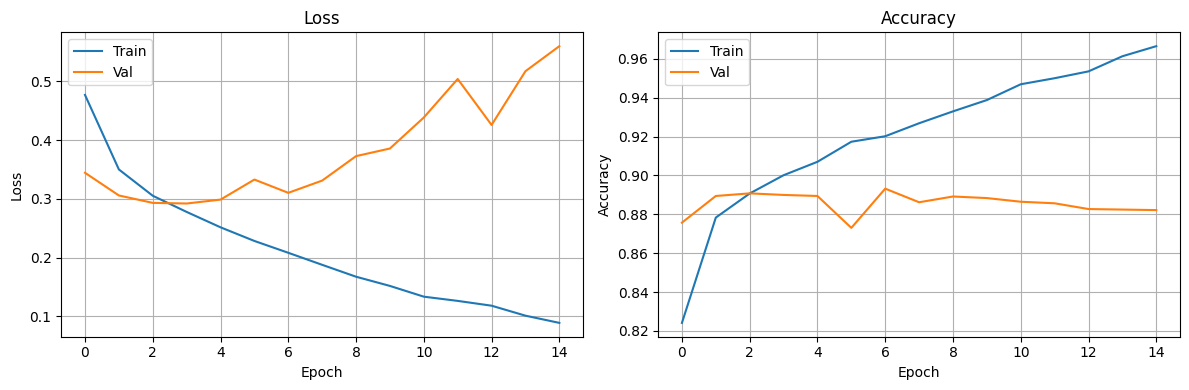

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'], label='Val')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['val_acc'], label='Val')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [25]:
model.load_state_dict(torch.load('best_model.pth'))
test_loss, test_acc, preds, true_labels = evaluate(model, test_loader, criterion, device)

print("=" * 50)
print("TEST RESULTS")
print("=" * 50)
print(f"Accuracy: {test_acc:.4f}")

class_names = ['Hate Speech', 'Offensive', 'Neither']
print("\nClassification Report:")
print(classification_report(true_labels, preds, target_names=class_names))

TEST RESULTS
Accuracy: 0.8973

Classification Report:
              precision    recall  f1-score   support

 Hate Speech       0.56      0.21      0.31       207
   Offensive       0.93      0.94      0.94      2878
     Neither       0.79      0.91      0.85       633

    accuracy                           0.90      3718
   macro avg       0.76      0.69      0.70      3718
weighted avg       0.89      0.90      0.89      3718



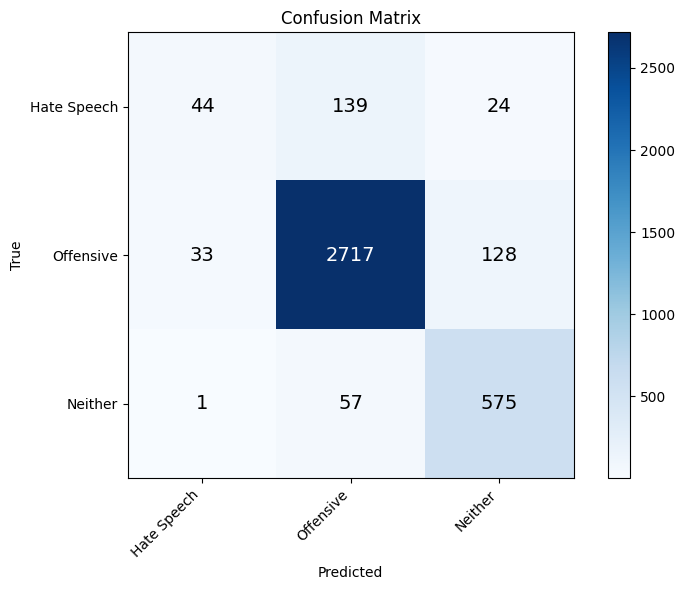

In [26]:
cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks([0, 1, 2], class_names, rotation=45, ha='right')
plt.yticks([0, 1, 2], class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
for i in range(3):
    for j in range(3):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=14)
plt.tight_layout()
plt.show()

In [27]:
def predict_tweet(text):
    model.eval()
    cleaned = clean_text(text)
    words = cleaned.split()
    word_ids, sents = tokenize_tweet(words, MAX_LEN)
    
    word_ids_t = torch.tensor([word_ids]).to(device)
    sents_t = torch.tensor([sents], dtype=torch.float).to(device)
    
    with torch.no_grad():
        output = model(word_ids_t, sents_t)
        probs = torch.softmax(output, dim=1)[0]
        pred = torch.argmax(probs).item()
    return pred, probs.cpu().numpy()

def demo(text):
    names = ['Hate Speech', 'Offensive', 'Neither']
    pred, probs = predict_tweet(text)
    print(f'Tweet: "{text}"')
    print(f'Prediction: {names[pred]}')
    for i, name in enumerate(names):
        bar = '█' * int(probs[i] * 20)
        print(f'  {name:12}: {probs[i]:.1%} {bar}')
    print()

# Test it!
demo("RT @user stupid bitch needs to die")
demo("I fucking hate these people")
demo("Happy birthday! Love you!")

Tweet: "RT @user stupid bitch needs to die"
Prediction: Offensive
  Hate Speech : 6.7% █
  Offensive   : 93.3% ██████████████████
  Neither     : 0.0% 

Tweet: "I fucking hate these people"
Prediction: Hate Speech
  Hate Speech : 50.5% ██████████
  Offensive   : 49.4% █████████
  Neither     : 0.1% 

Tweet: "Happy birthday! Love you!"
Prediction: Neither
  Hate Speech : 10.5% ██
  Offensive   : 31.5% ██████
  Neither     : 58.0% ███████████

